# 03 - Modeling

Neste notebook eu organizo a etapa de modelagem do projeto **Credit Risk Prediction**. O objetivo é comparar modelos de classificação binária para prever `TARGET`, usando o dataset processado e as features financeiras criadas na etapa anterior.

O treino principal fica no script `src/models/train_model.py`. Isso mantém o notebook mais limpo e ajuda a reproduzir o processo pela linha de comando.

## 1. Estratégia

A estratégia de modelagem segue estes passos:

1. carregar `data/processed/credit_risk_processed.csv`;
2. criar as features financeiras com `build_features`;
3. separar `X` e `y`, usando `TARGET` como alvo;
4. fazer split treino/teste estratificado;
5. aplicar um pipeline com imputação, escala para numéricas e one-hot encoding para categóricas;
6. treinar Logistic Regression, Random Forest, LightGBM e XGBoost;
7. comparar os modelos com ROC-AUC, PR-AUC, precision, recall, F1 e matriz de confusão.

Acurácia não é a métrica principal aqui. Como inadimplência é a classe minoritária, um modelo pode acertar muitos casos da classe `0` e ainda assim ser pouco útil para encontrar clientes com maior risco. Por isso, eu olho principalmente para PR-AUC, recall e precision da classe positiva.

## 2. Imports e caminhos

Este notebook lê os artefatos gerados pelo script de treino. Se os arquivos ainda não existirem, rode `python src/models/train_model.py`. Para um teste rápido local, use `--sample-size`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.config import DEFAULT_METRICS_PATH, DEFAULT_MODEL_PATH, FIGURES_DIR  # noqa: E402, I001

pd.set_option("display.float_format", "{:.4f}".format)

## 3. Como rodar o treino

Treino completo:

```bash
python src/models/train_model.py
```

Treino mais rápido para validar o pipeline localmente:

```bash
python src/models/train_model.py --sample-size 5000
```

O comando salva `reports/model_metrics.csv`, `models/credit_risk_model.pkl` e os gráficos principais em `reports/figures`.

## 4. Comparação dos modelos

A tabela abaixo vem diretamente do arquivo de métricas gerado pelo script. Assim, o notebook não depende de números digitados manualmente.

In [2]:
if not DEFAULT_METRICS_PATH.exists():
    raise FileNotFoundError(
        f"Metrics file not found at {DEFAULT_METRICS_PATH}. "
        "Run: python src/models/train_model.py --sample-size 5000"
    )

metrics = pd.read_csv(DEFAULT_METRICS_PATH)
metrics

,model,roc_auc,pr_auc,precision,recall,f1_score,threshold,true_negative,false_positive,false_negative,true_positive,sample_size,dataset_rows,train_rows,test_rows
0,random_forest,0.7586,0.2441,0.1852,0.4938,0.2694,0.5000,743,176,41,40,5000,5000,4000,1000
1,xgboost,0.7634,0.2344,0.2180,0.3580,0.2710,0.5000,815,104,52,29,5000,5000,4000,1000
2,lightgbm,0.7465,0.2201,0.2727,0.1481,0.1920,0.5000,887,32,69,12,5000,5000,4000,1000
3,logistic_regression,0.7122,0.1766,0.1567,0.5802,0.2467,0.5000,666,253,34,47,5000,5000,4000,1000


In [3]:
metric_columns = [
    "model",
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "f1_score",
    "false_positive",
    "false_negative",
]

display(metrics[metric_columns].sort_values(["pr_auc", "roc_auc"], ascending=False))

,model,roc_auc,pr_auc,precision,recall,f1_score,false_positive,false_negative
0,random_forest,0.7586,0.2441,0.1852,0.4938,0.2694,176,41
1,xgboost,0.7634,0.2344,0.2180,0.3580,0.2710,104,52
2,lightgbm,0.7465,0.2201,0.2727,0.1481,0.1920,32,69
3,logistic_regression,0.7122,0.1766,0.1567,0.5802,0.2467,253,34


## 5. Curvas e matriz de confusão

A curva ROC mostra a separação geral entre classes. A curva precision-recall costuma ser mais informativa neste projeto porque o `TARGET = 1` é minoria. A matriz de confusão ajuda a enxergar o efeito prático do threshold escolhido.

### ROC curve

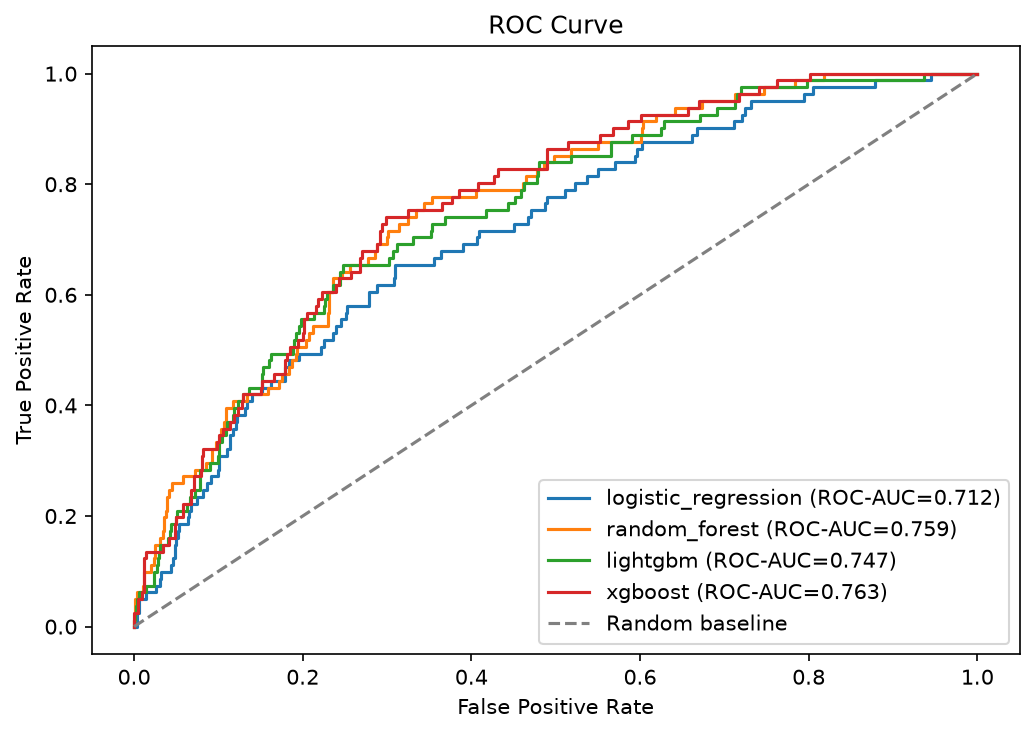

### Precision-recall curve

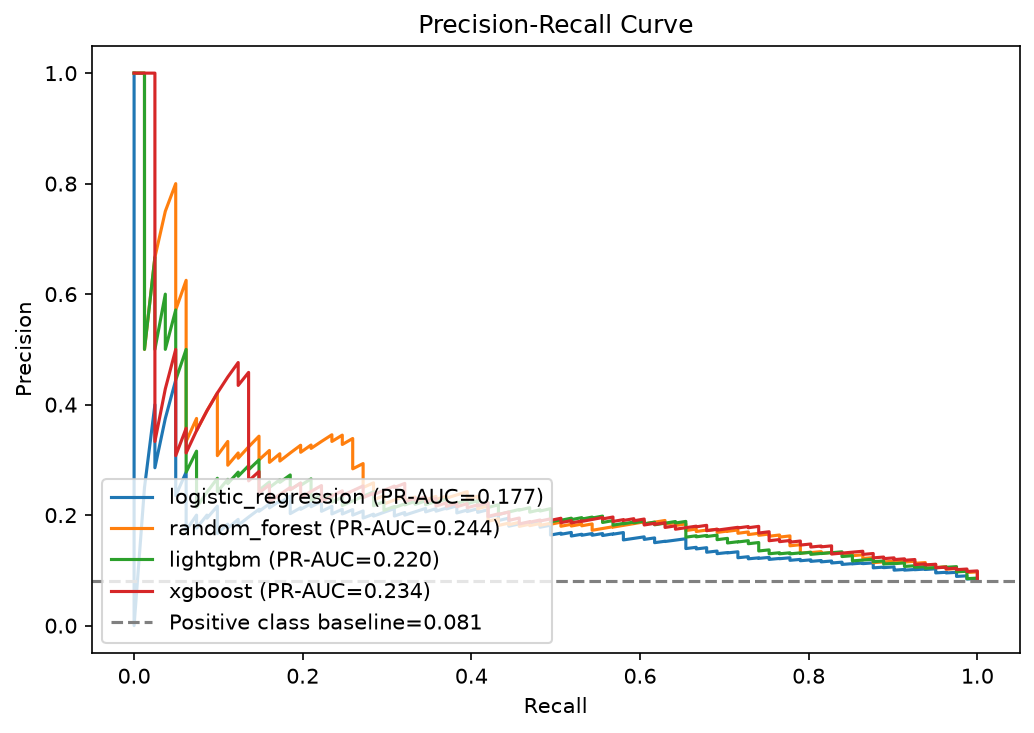

### Confusion matrix

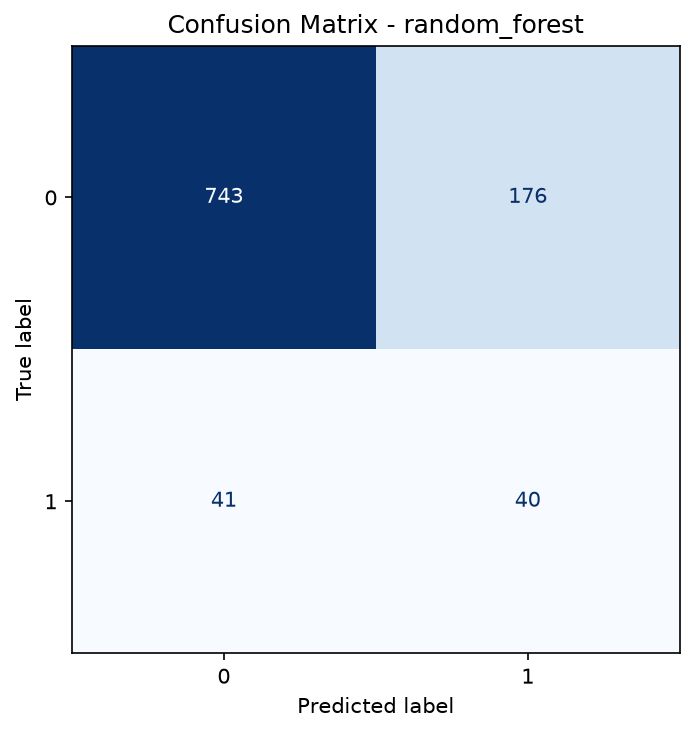

In [4]:
figure_paths = {
    "ROC curve": FIGURES_DIR / "roc_curve.png",
    "Precision-recall curve": FIGURES_DIR / "precision_recall_curve.png",
    "Confusion matrix": FIGURES_DIR / "confusion_matrix.png",
}

for title, path in figure_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Expected figure not found: {path}")
    display(Markdown(f"### {title}"))
    display(Image(filename=str(path)))

## 6. Modelo escolhido

Para esta versão inicial, escolho o melhor modelo pela maior `PR-AUC`. Essa métrica faz sentido porque mede a qualidade do ranqueamento quando a classe positiva é rara. A escolha ainda pode mudar quando eu ajustar threshold, testar validação cruzada e analisar custo de falso negativo versus falso positivo.

In [5]:
best_model = metrics.sort_values(["pr_auc", "roc_auc"], ascending=False).iloc[0]
sample_size = best_model.get("sample_size", pd.NA)

summary_lines = [
    f"Modelo escolhido nesta execução: **{best_model['model']}**.",
    f"PR-AUC: **{best_model['pr_auc']:.4f}**.",
    f"ROC-AUC: **{best_model['roc_auc']:.4f}**.",
    f"Recall da classe positiva: **{best_model['recall']:.4f}**.",
    f"Precision da classe positiva: **{best_model['precision']:.4f}**.",
]

if pd.notna(sample_size):
    summary_lines.append(
        f"Esta execução usou uma amostra de **{int(sample_size):,} linhas**. Para resultado final, rode sem `--sample-size`."
    )
else:
    summary_lines.append("Esta execução usou o dataset processado completo.")

summary_lines.append(f"Artefato salvo em `{DEFAULT_MODEL_PATH}`.")

display(Markdown("\n".join(f"- {line}" for line in summary_lines)))

- Modelo escolhido nesta execução: **random_forest**.
- PR-AUC: **0.2441**.
- ROC-AUC: **0.7586**.
- Recall da classe positiva: **0.4938**.
- Precision da classe positiva: **0.1852**.
- Esta execução usou uma amostra de **5,000 linhas**. Para resultado final, rode sem `--sample-size`.
- Artefato salvo em `C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\models\credit_risk_model.pkl`.

## Main takeaways

- PR-AUC é a métrica principal desta comparação inicial porque o problema é desbalanceado.
- A matriz de confusão deve ser lida junto com o threshold usado; melhorar recall pode aumentar falsos positivos.
- O melhor modelo desta execução é um ponto de partida, não uma conclusão final. Ainda falta otimizar hiperparâmetros, calibrar threshold e avaliar explicabilidade.